***Loading packages***

In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import networkx as nx
import seaborn as sns
import igraph as ig
from geopy.distance import geodesic
from scipy.stats import pearsonr
from pathlib import Path
import statsmodels
import statsmodels.api as sm

# Locate the project root regardless of where the notebook is executed from
cwd = Path.cwd()

if (cwd / "src").exists() and (cwd / "external").exists():
    project_root = cwd
elif (cwd.parent / "src").exists() and (cwd.parent / "external").exists():
    project_root = cwd.parent
else:
    raise RuntimeError("Could not locate the project root.")

sys.path.append(str(project_root / "external"))
sys.path.append(str(project_root / "src"))

import importlib
import edge_baselines
importlib.reload(edge_baselines)
import simulation
importlib.reload(simulation)
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX



from real_data_pipeline import (build_baboon_edge_graph, run_baseline_comparison,
                                 run_gnar_edge_rolling_multicov, edge_weights_distribution,
                                 run_full_sweep, build_stages_per_lag)
from simulation import (
    # Network generation
    calibrate_rdp_radius,
    get_or_calibrate_rdp_radius,
    generate_network,
    simulate_node_covariates,
    build_synthetic_edge_covariates,

    # Time-series simulation
    simulate_ar1_exog,
    simulate_full_model,

    # Graph and design-matrix utilities
    build_W_matrices,
    build_design_matrix,
    compute_ols_standard_errors,

    # Monte Carlo simulation
    run_full_simulation_replication,
    run_large_network_replication_density,
    run_single_step_prediction_replication,
    run_single_step_prediction_replication_learner,
    run_single_step_prediction_replication_with_dfm,
    run_dgp_fixed_model_comparison_replication,

    # Regime construction
    expand_R_by_l,
    build_beta_dict,
    build_regime,

    # Results tables
    build_per_parameter_table,
    build_aggregated_table4_style,

    # Small helper
    format_tuple_list,
    format_as_multiindex
)
from BaseEdgeGNAR_edge import GNAREdgeLearner
from BaseEdgeGNAR_edge_global import GNAREdgeGlobalLearner
from BaseEdge import EdgeTrainSet
from edge_graph import ArrayEdgeGraph
from RollingEdgePredict import RollingEdgePredict
from model import build_edge_covariate, GNAREdgeGlobalMultiCovLearner
from diagnostics import check_gnar_stationarity_eigenvalues, run_residual_diagnostics_pooled, save_table, save_figure
from edge_baselines import compare_baselines, NaiveEdgeBaseline, ARIMAEdgeBaseline, DFMEdgeBaseline 

#loading external data
interactions_path = project_root / "data" / "baboons_proximity_data.txt"
max_temp_path = project_root / "data" / "trets.csv"
baboon_data_path = project_root / "data" / "baboon_data.csv"

table_dir = project_root / "notebooks" / "output" / "tables"
figures_dir = project_root / "notebooks" / "output" / "figures"

***Predictive Performance for Moderately Sized Networks***

Defining Simulation Regimes

In [2]:
_rdp_radius_cache = {}

paper_regimes = {
    # gnar-edge paper regimes
    1: {"L": 1, "R_max": [1],       "alpha": [0.2],             "beta_vals": [0.3],
        "gamma_edge_cov": {}, "gamma_time_cov": 0.0, "interaction_pairs": [], "gamma_interaction": {}},
    2: {"L": 1, "R_max": [2],       "alpha": [0.2],             "beta_vals": [(0.3, 0.4)],
        "gamma_edge_cov": {}, "gamma_time_cov": 0.0, "interaction_pairs": [], "gamma_interaction": {}},
    3: {"L": 3, "R_max": [1, 1, 1], "alpha": [0.2, 0.4, -0.6],  "beta_vals": [0.2, 0.1, -0.2],
        "gamma_edge_cov": {}, "gamma_time_cov": 0.0, "interaction_pairs": [], "gamma_interaction": {}},
    4: {"L": 3, "R_max": [2, 2, 2], "alpha": [0.2, 0.4, -0.6],  "beta_vals": [(0.3, 0.1), (0.1, 0.1), (-0.2, 0.3)],
        "gamma_edge_cov": {}, "gamma_time_cov": 0.0, "interaction_pairs": [], "gamma_interaction": {}},
    5: {"L": 3, "R_max": [2, 0, 0], "alpha": [0.2, 0.4, -0.6],  "beta_vals": [(0.3, 0.4)],
        "gamma_edge_cov": {}, "gamma_time_cov": 0.0, "interaction_pairs": [], "gamma_interaction": {}},

    # new regimes with covariates, exogenous series, and/or interactions
    6: {"L": 3, "R_max": [2, 2, 2],
        "alpha": [0.2, 0.4, -0.6],
        "beta_vals": [(0.3, 0.1), (0.1, 0.1), (-0.2, 0.3)],
        "gamma_edge_cov": {"age_diff": 0.05, "mean_age": 0.03}, "gamma_time_cov": 0.0,
        "interaction_pairs": [], "gamma_interaction": {}},
    7: {"L": 3, "R_max": [2, 2, 2],
        "alpha": [0.2, 0.4, -0.6],
        "beta_vals": [(0.3, 0.1), (0.1, 0.1), (-0.2, 0.3)],
        "gamma_edge_cov": {}, "gamma_time_cov": 0.2,
        "interaction_pairs": [], "gamma_interaction": {}},
    8: {"L": 3, "R_max": [2, 2, 2],
        "alpha": [0.2, 0.4, -0.6],
        "beta_vals": [(0.3, 0.1), (0.1, 0.1), (-0.2, 0.3)],   #matches regime 4 exactly
        "gamma_edge_cov": {"age_diff": 0.05, "mean_age": 0.03}, "gamma_time_cov": 0.2,
        "interaction_pairs": [], "gamma_interaction": {}},
    9: {"L": 3, "R_max": [2, 2, 2],
        "alpha": [0.2, 0.4, -0.6],
        "beta_vals": [(0.3, 0.1), (0.1, 0.1), (-0.2, 0.3)],   #matches regime 4 exactly
        "gamma_edge_cov": {"age_diff": 0.05, "mean_age": 0.03}, "gamma_time_cov": 0.2,
        "interaction_pairs": [("mean_age", "sim_temp")], "gamma_interaction": {("mean_age", "sim_temp"): 0.02}},
}

#predicting for regimes 4, 8 and 9
prediction_regimes = {
    "no_covariates (regime 4)": paper_regimes[4],          
    "with_covariates_no_interaction (regime 8)": paper_regimes[8],
    "with_covariates_interaction (regime 9)": paper_regimes[9],
}

Generating moderately sized networks and predicting the next time step

In [ ]:
QUICK_TEST = False  # set False for the full run

if QUICK_TEST: #test run to check all the code is running properly
    regimes_to_run = ["no_covariates (regime 4)"]
    structures_to_run = ["SBM"]
    densities_to_run = [0.4]
    n_replications = 1
    K = 10
    T = 20
else: #full run, same as used in dissertation
    regimes_to_run = list(prediction_regimes.keys())
    structures_to_run = ["ER", "SBM", "RDP"]
    densities_to_run = [0.4]
    n_replications = 50
    K = 20
    T = 500

prediction_results = []

#looping over regimes
for regime_key in regimes_to_run:
    regime_spec = prediction_regimes[regime_key]
    #converting regime to format expected by simulation functions
    R_by_l = expand_R_by_l(regime_spec["R_max"])
    beta_dict = build_beta_dict(R_by_l, regime_spec["beta_vals"])

    #looping over structures
    for structure in structures_to_run:
        for density in densities_to_run:
            #number of replications depends on whether doing a full run or quick test
            for rep in range(n_replications):
                res = run_single_step_prediction_replication(
                    K=K,
                    density=density,
                    structure=structure,
                    rdp_radius_cache=_rdp_radius_cache,
                    L=regime_spec["L"],
                    stages_per_lag=R_by_l,
                    true_alpha=regime_spec["alpha"],
                    true_beta_dict=beta_dict,
                    true_gamma_edge_cov=regime_spec["gamma_edge_cov"],
                    true_gamma_time_cov=regime_spec["gamma_time_cov"],
                    interaction_pairs=regime_spec["interaction_pairs"],
                    true_gamma_interaction=regime_spec["gamma_interaction"],
                    T=T,
                    seed=rep,
                    arima_order="auto",
                )
                res.update({
                    "regime": regime_key,
                    "structure": structure,
                    "density": density,
                    "seed": rep,
                })
                prediction_results.append(res)

prediction_df = pd.DataFrame(prediction_results)

KeyboardInterrupt: 

Appending DFM results to previous prediction results, using the same seed for each replication so comparisons are valid

In [ ]:

dfm_results = []
#converting regimes into format expected by simulation functions
for regime_label, regime_spec in prediction_regimes.items():
    R_by_l = expand_R_by_l(regime_spec["R_max"])
    beta_dict = build_beta_dict(R_by_l, regime_spec["beta_vals"])
    #looping over structures
    for structure in ["ER", "SBM", "RDP"]:
        for density in [0.4]:
            for rep in range(n_replications):
                #running dfm replication with exactly same parameters and seed as previous experiments
                res = run_single_step_prediction_replication_with_dfm(
                    K=20, density=density, structure=structure,
                    L=regime_spec["L"], stages_per_lag=R_by_l,
                    true_alpha=regime_spec["alpha"], true_beta_dict=beta_dict,
                    true_gamma_edge_cov=regime_spec["gamma_edge_cov"],
                    true_gamma_time_cov=regime_spec["gamma_time_cov"],
                    interaction_pairs=regime_spec["interaction_pairs"],
                    true_gamma_interaction=regime_spec["gamma_interaction"],
                    T=500, seed=rep, rdp_radius_cache=_rdp_radius_cache,
                )
                res.update({"regime": regime_label, "structure": structure, "density": density, "seed": rep})
                dfm_results.append(res)

dfm_df = pd.DataFrame(dfm_results)

#merging the results
merged_df = prediction_df.merge(
    dfm_df[["regime", "structure", "density", "seed", "dfm"]],
    on=["regime", "structure", "density", "seed"],
)

display(merged_df)

,gnar_with_neighbours,gnar_no_neighbours,arima,regime,structure,density,seed,dfm
0,0.960894,5.191521,8.935223,no_covariates (regime 4),ER,0.1,0,5534.554038
1,1.021871,1.170382,1.243573,no_covariates (regime 4),ER,0.1,1,72.985666
2,0.905288,1.146115,1.218715,no_covariates (regime 4),ER,0.1,2,11964.364447
3,1.119264,1.177160,1.391696,no_covariates (regime 4),ER,0.1,3,60115.235059
4,0.965759,1.090341,1.391091,no_covariates (regime 4),ER,0.1,4,7.153951
...,...,...,...,...,...,...,...,...
895,1.045551,1.413891,1.786547,with_covariates_interaction (regime 9),RDP,0.4,45,1.933465
896,2.021127,2.023377,1.627806,with_covariates_interaction (regime 9),RDP,0.4,46,2.672007
897,1.097454,1.242126,1.647695,with_covariates_interaction (regime 9),RDP,0.4,47,1.509957
898,1.317978,1.346797,1.987690,with_covariates_interaction (regime 9),RDP,0.4,48,1.955356


Laying out results as a table

In [ ]:

melted = merged_df.melt(
    id_vars=["regime", "structure", "density"],
    value_vars=["gnar_with_neighbours", "gnar_no_neighbours", "arima", "dfm"],
    var_name="model", value_name="rmse"
)

#computing median rmse for each (regime, density, structure, model) combination
summary = (
    melted.groupby(["regime", "density", "structure", "model"])["rmse"]
    .agg(median="median")
)

# format single median column
summary["RMSE"] = summary["median"].round(3).astype(str)

#export to latex
table = summary["RMSE"].unstack("model")
table.to_latex(
    escape=True,
    multicolumn=True,
    multirow=True,
    caption=""
)
display(table)

model                                                         arima      dfm  \
regime                                    density structure                    
no_covariates (regime 4)                  0.1     ER          2.012    3.538   
                                                  RDP        299.47   41.711   
                                                  SBM          5.43   16.757   
                                          0.4     ER          1.222      1.4   
                                                  RDP         1.226    1.433   
                                                  SBM         1.214    1.442   
with_covariates_interaction (regime 9)    0.1     ER          4.252    7.351   
                                                  RDP        51.942  113.458   
                                                  SBM        43.032    9.644   
                                          0.4     ER          1.671    1.763   
                                                  RDP         1.691    1.758   
                                                  SBM         1.761    1.765   
with_covariates_no_interaction (regime 8) 0.1     ER         17.655    3.118   
                                                  RDP        22.034   134.15   
                                                  SBM        15.451   17.555   
                                          0.4     ER           1.37    1.518   
                                                  RDP         1.391    1.516   
                                                  SBM         1.349     1.51   

model                                                       gnar_no_neighbours  \
regime                                    density structure                      
no_covariates (regime 4)                  0.1     ER                     1.234   
                                                  RDP                    1.817   
                                                  SBM                     1.23   
                                          0.4     ER                     1.039   
                                                  RDP                    1.002   
                                                  SBM                    1.047   
with_covariates_interaction (regime 9)    0.1     ER                     2.016   
                                                  RDP                    3.478   
                                                  SBM                    2.182   
                                          0.4     ER                      1.44   
                                                  RDP                    1.413   
                                                  SBM                    1.396   
with_covariates_no_interaction (regime 8) 0.1     ER                     1.617   
                                                  RDP                    2.215   
                                                  SBM                    1.771   
                                          0.4     ER                     1.217   
                                                  RDP                    1.193   
                                                  SBM                     1.23   

model                                                       gnar_with_neighbours  
regime                                    density structure                       
no_covariates (regime 4)                  0.1     ER                       1.093  
                                                  RDP                      1.086  
                                                  SBM                      1.034  
                                          0.4     ER                       1.009  
                                                  RDP                      0.979  
                                                  SBM                      1.023  
with_covariates_interaction (regime 9)    0.1     ER                       1.319  
           

Plotting results comparison against baseline models

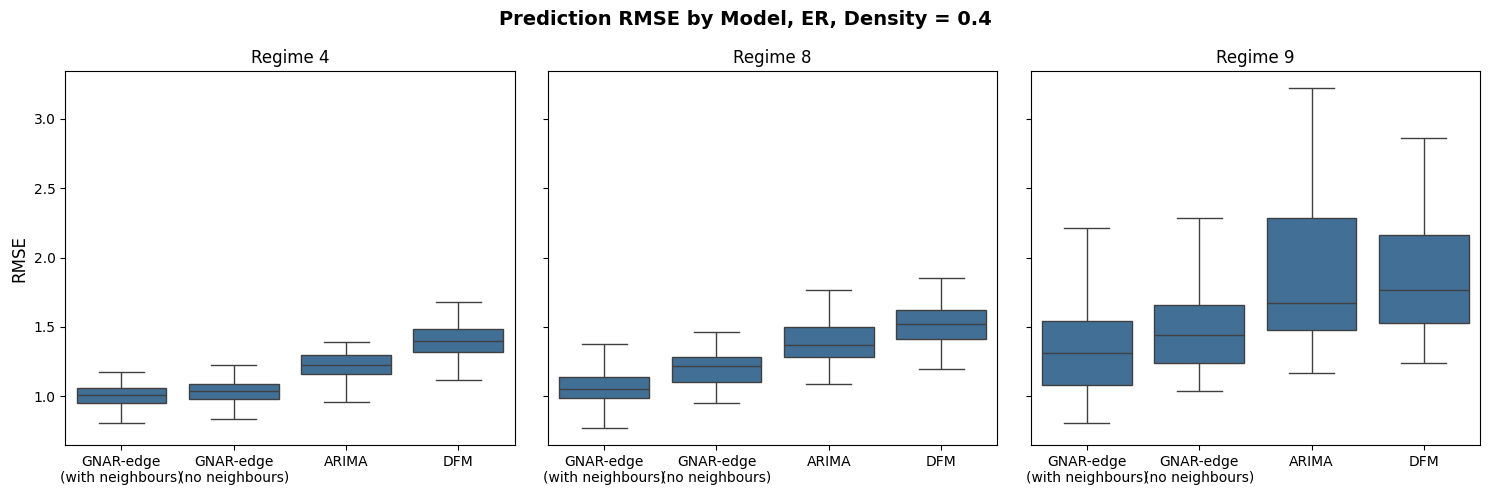

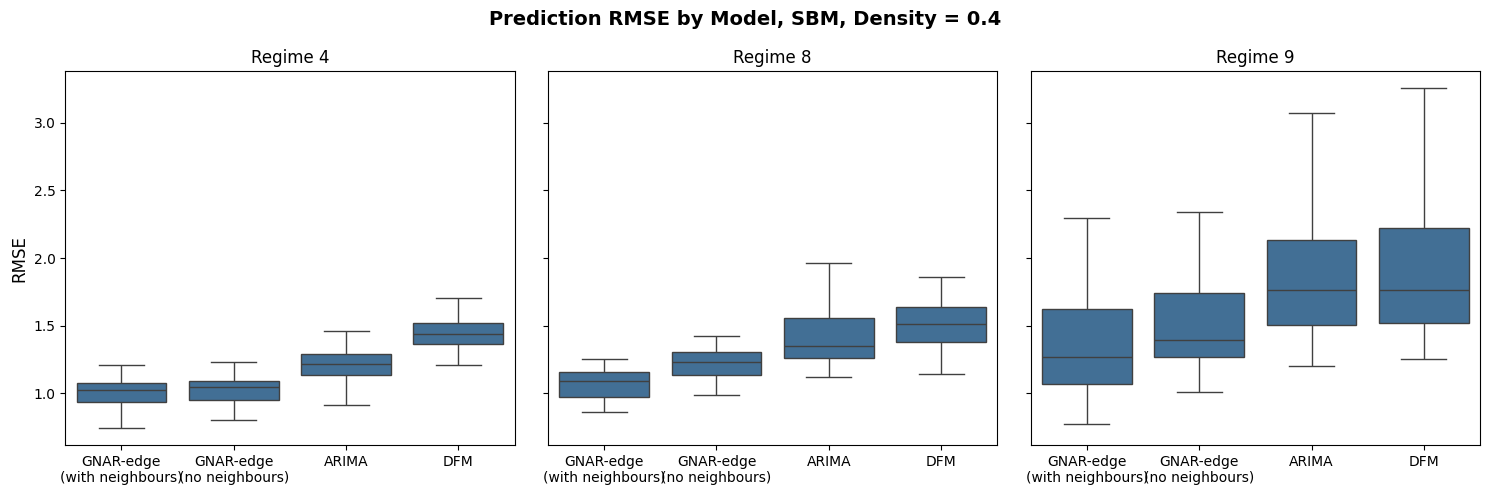

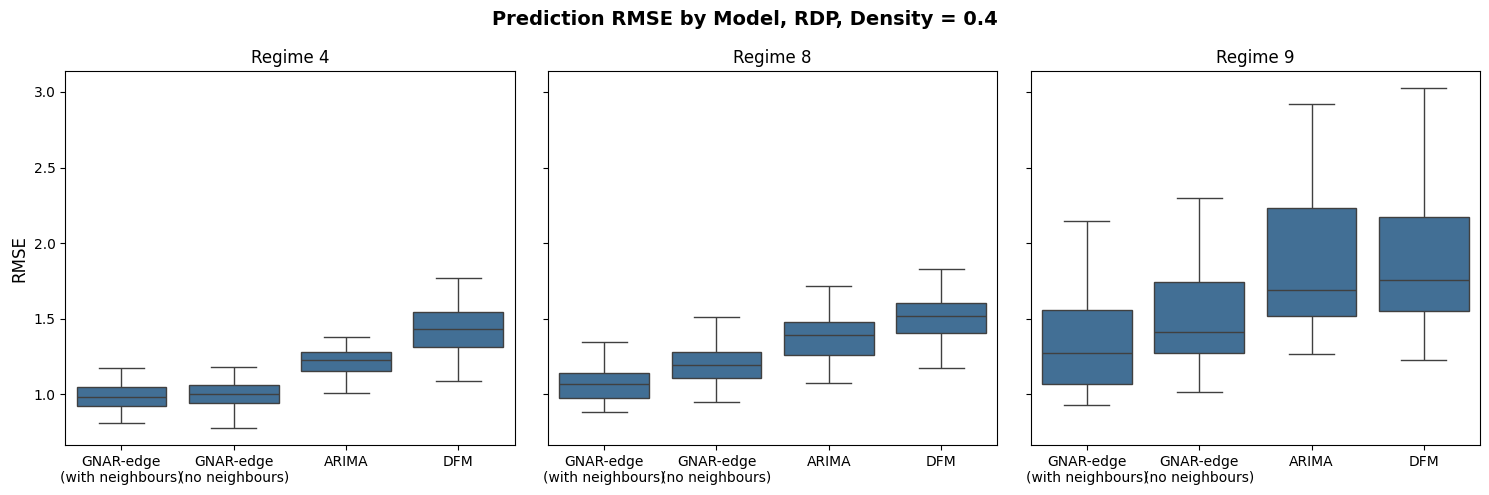

In [ ]:
melted_pred = merged_df.melt(
    id_vars=["regime", "structure", "density", "seed"],
    value_vars=["gnar_with_neighbours", "gnar_no_neighbours", "arima", "dfm"],
    var_name="model", value_name="rmse",
).dropna(subset=["rmse"])

#renaming models for presentation purposes
melted_pred["model"] = melted_pred["model"].replace({
    "gnar_with_neighbours": "GNAR-edge\n(with neighbours)",
    "gnar_no_neighbours": "GNAR-edge\n(no neighbours)",
    "arima": "ARIMA", "dfm": "DFM",
})

#renaming regimes for presentation purposes
regime_display_names = {
    "no_covariates (regime 4)": "Regime 4",
    "with_covariates_no_interaction (regime 8)": "Regime 8",
    "with_covariates_interaction (regime 9)": "Regime 9",
}

model_order = ["GNAR-edge\n(with neighbours)", "GNAR-edge\n(no neighbours)", "ARIMA", "DFM"]

for density in [0.4]:
    #one plot for each structure
    for structure in ["ER", "SBM", "RDP"]:
        subset = melted_pred[(melted_pred["density"] == density) & (melted_pred["structure"] == structure)]

        fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

        for ax, regime in zip(axes, prediction_regimes.keys()):
            regime_subset = subset[subset["regime"] == regime]
            display_name = regime_display_names.get(regime, regime)

            sns.boxplot(
                data=regime_subset, x="model", y="rmse",
                order=model_order, color="#3470a3", showfliers=False, ax=ax,
            )
            ax.set_title(display_name, fontsize=12)
            ax.set_xlabel("")
            ax.set_ylabel("RMSE" if regime == list(prediction_regimes.keys())[0] else "", fontsize=12)
            ax.tick_params(axis="x", rotation=0)

        fig.suptitle(f"Prediction RMSE by Model, {structure}, Density = {density}", fontsize=14, fontweight="bold")
        save_figure(fig, f"prediction_rmse_regimes_{structure.lower()}_density{str(density).replace('.', '')}")
        plt.show()

***Moderately sized Networks: Investigating whether explicitly modelling genuinely present interaction terms improves predictive performance***

Fixing DGP at regime 9, but fitting 3 different GNAR-edge models:
1. covariate-free model
2. with covariates but excluding interaction term
3. with covariates and an interaction term

In [ ]:

#fixing dgp to regime 9
regime_full_dgp = paper_regimes[9] 
#convering regime to format expected by simulation functions
R_by_l = expand_R_by_l(regime_full_dgp["R_max"])
beta_dict = build_beta_dict(R_by_l, regime_full_dgp["beta_vals"])

n_replications = 50
comparison_results = []

#looping over structures
for structure in ["ER", "SBM", "RDP"]:
    for density in [0.4]:
        #repeating n_replications times
        for rep in range(n_replications):
            res = run_dgp_fixed_model_comparison_replication(
                K=20, density=density, structure=structure,
                rdp_radius_cache = _rdp_radius_cache,
                L=regime_full_dgp["L"], stages_per_lag=R_by_l,
                true_alpha=regime_full_dgp["alpha"], true_beta_dict=beta_dict,
                true_gamma_edge_cov=regime_full_dgp["gamma_edge_cov"],
                true_gamma_time_cov=regime_full_dgp["gamma_time_cov"],
                interaction_pairs=regime_full_dgp["interaction_pairs"],
                true_gamma_interaction=regime_full_dgp["gamma_interaction"],
                T=500, seed=rep,
            )
            res.update({"structure": structure, "density": density, "seed": rep})
            comparison_results.append(res)

comparison_df = pd.DataFrame(comparison_results)

#computing median rmse for each model
median_by_model = (
    comparison_df.melt(id_vars=["structure","density"], 
                        value_vars=["correctly_specified","covariates_no_interaction","no_covariates_fitted"],
                        var_name="fitted_model", value_name="rmse")
    .groupby(["structure","density","fitted_model"])["rmse"].median()
    .reset_index()
)
print(median_by_model)

/Users/admin/baboon-gnar-edge/src/model.py:109: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  z_tensor = torch.as_tensor(time_covariates[name], dtype=pred.dtype, device=pred.device).view(-1, 1)  # (N,1)


Calibrated RDP radius for K=20, density=0.1000: radius=0.553, achieved=0.097
Calibrated RDP radius for K=20, density=0.4000: radius=1.188, achieved=0.386
   structure  density               fitted_model      rmse
0         ER      0.1        correctly_specified  1.390081
1         ER      0.1  covariates_no_interaction  1.496949
2         ER      0.1       no_covariates_fitted  1.713716
3         ER      0.4        correctly_specified  1.257757
4         ER      0.4  covariates_no_interaction  1.292087
5         ER      0.4       no_covariates_fitted  1.474023
6        RDP      0.1        correctly_specified  1.552348
7        RDP      0.1  covariates_no_interaction  1.781202
8        RDP      0.1       no_covariates_fitted  1.967808
9        RDP      0.4        correctly_specified  1.271322
10       RDP      0.4  covariates_no_interaction  1.298603
11       RDP      0.4       no_covariates_fitted  1.446705
12       SBM      0.1        correctly_specified  1.509346
13       SBM      0.

Repeating the experiments but varying the scale of the exogenous coefficients

In [ ]:
#scales of exogenous covariates under consideration
gamma_scale_regimes = {
    "small": {
        "gamma_edge_cov": {"age_diff": 0.05, "mean_age": 0.03},
        "gamma_time_cov": 0.2,
        "gamma_interaction": {("mean_age", "sim_temp"): 0.02},
    },
    "moderate": {
        "gamma_edge_cov": {"age_diff": 0.15, "mean_age": 0.10},
        "gamma_time_cov": 0.5,
        "gamma_interaction": {("mean_age", "sim_temp"): 0.08},
    },
    "large": {
        "gamma_edge_cov": {"age_diff": 0.30, "mean_age": 0.25},
        "gamma_time_cov": 1.0,
        "gamma_interaction": {("mean_age", "sim_temp"): 0.20},
    },
}




n_replications = 50
gamma_scale_results = []

for scale_label, gamma_spec in gamma_scale_regimes.items():
    regime_full_dgp = paper_regimes[9]   #endogenous component (L, R_max, alpha, beta) stays the same
    R_by_l = expand_R_by_l(regime_full_dgp["R_max"])
    beta_dict = build_beta_dict(R_by_l, regime_full_dgp["beta_vals"])

    #looping over strcutres
    for structure in ["ER", "SBM", "RDP"]:
        for density in [0.4]:
            #repeating n_replications times
            for rep in range(n_replications):
                res = run_dgp_fixed_model_comparison_replication(
                    K=20, density=density, structure=structure,
                    rdp_radius_cache = _rdp_radius_cache,
                    L=regime_full_dgp["L"], stages_per_lag=R_by_l,
                    true_alpha=regime_full_dgp["alpha"], true_beta_dict=beta_dict,
                    true_gamma_edge_cov=gamma_spec["gamma_edge_cov"],
                    true_gamma_time_cov=gamma_spec["gamma_time_cov"],
                    interaction_pairs=[("mean_age", "sim_temp")],
                    true_gamma_interaction=gamma_spec["gamma_interaction"],
                    T=500, seed=rep,
                )
                res.update({"gamma_scale": scale_label, "structure": structure, "density": density, "seed": rep})
                gamma_scale_results.append(res)

gamma_scale_df = pd.DataFrame(gamma_scale_results)

,Scale,Edge covariates,Time covariate,Interaction
0,small,"age_diff = 0.05, mean_age = 0.03",0.2,mean_age × sim_temp = 0.02
1,moderate,"age_diff = 0.15, mean_age = 0.10",0.5,mean_age × sim_temp = 0.08
2,large,"age_diff = 0.30, mean_age = 0.25",1.0,mean_age × sim_temp = 0.20


Building a table that presents the exogenous coefficient scales under consideration

In [ ]:

gamma_scale_table = pd.DataFrame([
    {
        "Scale": "Small",
        "Edge covariates": "Age diff = 0.05, Mean age = 0.03",
        "Time covariate": 0.20,
        "Interaction": "Mean Age × Temp = 0.02",
    },
    {
        "Scale": "Moderate",
        "Edge covariates": "Age diff = 0.15, Mean age = 0.10",
        "Time covariate": 0.50,
        "Interaction": "Mean age × Temp = 0.08",
    },
    {
        "Scale": "Large",
        "Edge covariates": "Age diff = 0.30, Mean age = 0.25",
        "Time covariate": 1.00,
        "Interaction": "Mean age × Temp = 0.20",
    },
])

display(gamma_scale_table)


save_table(gamma_scale_table, "gamma_scale_table")
gamma_scale_table.to_latex(
    table_dir / "gamma_scale_table.tex",
    escape = True,
        multicolumn = True,
        multirow = True,
        caption = "Exogenous covariate specifications considered to examine how the importance of correctly specifying the exogenous component depends on the scale of the exogenous effect."  
)

,Scale,Edge covariates,Time covariate,Interaction
0,Small,"Age diff = 0.05, Mean age = 0.03",0.2,Mean Age × Temp = 0.02
1,Moderate,"Age diff = 0.15, Mean age = 0.10",0.5,Mean age × Temp = 0.08
2,Large,"Age diff = 0.30, Mean age = 0.25",1.0,Mean age × Temp = 0.20


Presenting the results

In [ ]:

# median RMSE
median_by_scale = (
    gamma_scale_df.melt(
        id_vars=["gamma_scale", "structure", "density"],
        value_vars=[
            "correctly_specified",
            "covariates_no_interaction",
            "no_covariates_fitted",
        ],
        var_name="fitted_model",
        value_name="rmse",
    )
    .groupby(["gamma_scale", "fitted_model", "structure", "density"])["rmse"]
    .median()
)


tables = {}

#one table for each scale
for scale in ["small", "moderate", "large"]:
    tables[scale] = (
        median_by_scale
        .loc[scale]
        .unstack(["structure", "density"])
        .round(3)
    )

small_df = tables["small"]
moderate_df = tables["moderate"]
large_df = tables["large"]

display(small_df)
display(moderate_df)
display(large_df)



structure                     ER           RDP           SBM       
density                      0.1    0.4    0.1    0.4    0.1    0.4
fitted_model                                                       
correctly_specified        1.451  1.248  1.552  1.271  1.617  1.278
covariates_no_interaction  1.364  1.364  1.781  1.299  1.767  1.345
no_covariates_fitted       1.828  1.480  1.968  1.447  2.390  1.518

structure                     ER           RDP           SBM       
density                      0.1    0.4    0.1    0.4    0.1    0.4
fitted_model                                                       
correctly_specified        3.183  2.863  3.828  2.836  3.658  2.814
covariates_no_interaction  3.956  2.850  4.397  2.782  4.428  2.900
no_covariates_fitted       4.282  3.311  4.577  3.234  5.692  3.126

structure                     ER           RDP           SBM       
density                      0.1    0.4    0.1    0.4    0.1    0.4
fitted_model                                                       
correctly_specified        7.368  6.496  7.438  6.398  7.874  6.582
covariates_no_interaction  7.849  6.226  9.079  6.127  7.159  6.126
no_covariates_fitted       8.409  7.266  9.556  7.128  9.685  7.314

***Simulation experiments for networks similar to the real data application***

In [4]:
#parameter regime used to resemble real data set
regime_full_dgp = {
    "L": 5,
    "R_max": [1, 1, 1, 1, 1],
    "alpha": [-0.51, -0.35, -0.24, -0.20, -0.10],
    "beta_vals": [0.06, 0.09, 0.26, 0.22, 0.18],
    "gamma_edge_cov": {"age_diff": 0.05, "mean_age": 0.03},
    "gamma_time_cov": 0.2,
    "interaction_pairs": [("mean_age", "sim_temp")],
    "gamma_interaction": {("mean_age", "sim_temp"): 0.02},
}

  
R_by_l = expand_R_by_l(regime_full_dgp["R_max"])
beta_dict = build_beta_dict(R_by_l, regime_full_dgp["beta_vals"])

#real baboon network's density
K_real = 13
density_real = 34 / (13 * 12 / 2)   #recompute to confirm exact value, ~0.436
print(f"Target density: {density_real:.4f}")

#calibrating rdp radius needed to produce target density for rdp graph
radius_real, achieved_real = calibrate_rdp_radius(K=13, target_density=density_real, n_trials=30)
print(f"K=13, density={density_real:.3f}: radius={radius_real:.3f}, achieved={achieved_real:.3f}")


n_replications = 50
baboon_comparison_results = []

#running replications for each network structure
for structure in ["ER", "SBM", "RDP"]:
    for rep in range(50):
        res = run_single_step_prediction_replication(
            K=K_real, density=density_real, structure=structure,
            rdp_radius_cache = _rdp_radius_cache,
            L=regime_full_dgp["L"], stages_per_lag=R_by_l,
            true_alpha=regime_full_dgp["alpha"], true_beta_dict=beta_dict,
            true_gamma_edge_cov=regime_full_dgp["gamma_edge_cov"],
            true_gamma_time_cov=regime_full_dgp["gamma_time_cov"],
            interaction_pairs=regime_full_dgp["interaction_pairs"],
            true_gamma_interaction=regime_full_dgp["gamma_interaction"],
            T=28, seed=rep,
        )
        res.update({"structure": structure, "seed": rep})
        baboon_comparison_results.append(res)


baboon_comparison_df = pd.DataFrame(baboon_comparison_results)

#DFM results for baboon-sized networks, matching the same seeds/regime as baboon_comparison_df
baboon_dfm_results = []

for structure in ["ER", "SBM", "RDP"]:
    for rep in range(n_replications):
        res = run_single_step_prediction_replication_with_dfm(
            K=K_real, density=density_real, structure=structure,
            L=regime_full_dgp["L"], stages_per_lag=R_by_l,
            true_alpha=regime_full_dgp["alpha"], true_beta_dict=beta_dict,
            true_gamma_edge_cov=regime_full_dgp["gamma_edge_cov"],
            true_gamma_time_cov=regime_full_dgp["gamma_time_cov"],
            interaction_pairs=regime_full_dgp["interaction_pairs"],
            true_gamma_interaction=regime_full_dgp["gamma_interaction"],
            T=28, seed=rep, rdp_radius_cache=_rdp_radius_cache,
        )
        res.update({"structure": structure, "seed": rep})
        baboon_dfm_results.append(res)

baboon_dfm_df = pd.DataFrame(baboon_dfm_results)

#merge into the existing baboon_comparison_df on the shared keys
baboon_comparison_df = baboon_comparison_df.merge(
    baboon_dfm_df[["structure", "seed", "dfm"]],
    on=["structure", "seed"],
)

display(baboon_comparison_df)

Target density: 0.4359
K=13, density=0.436: radius=1.369, achieved=0.411


/Users/admin/baboon-gnar-edge/src/model.py:106: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  z_tensor = torch.as_tensor(time_covariates[name], dtype=pred.dtype, device=pred.device).view(-1, 1)  # (N,1)


[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=0.8222694903261244 train_set_time=0.000s fit_time=4.023s stop=per_edge_closed_form
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=0.537910508202085 train_set_time=0.000s fit_time=7.377s stop=per_edge_closed_form
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=1.7794530856853392 train_set_time=0.000s fit_time=4.464s stop=per_edge_closed_form
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=2.0230170442689945 train_set_time=0.000s fit_time=5.343s stop=per_edge_closed_form
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=0.4569315639737947 train_set_time=0.000s fit_time=6.566s stop=per_edge_closed_form
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=1.8601713333386602 train_set_time=0.000s fit_time=4.471s stop=per_edge_closed_form
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=0.7138550852355533 train_set_time=0.000s fit_time=4.063s stop=per_edge_close

,gnar_with_neighbours,gnar_no_neighbours,arima,structure,seed,dfm
0,1.260257,1.395432,1.672098,ER,0,0.999926
1,0.971230,0.940929,1.491419,ER,1,1.201115
2,2.477482,2.489499,2.775074,ER,2,2.112325
3,1.613519,1.689079,2.170647,ER,3,1.218702
4,1.277233,1.320073,1.229050,ER,4,1.118173
...,...,...,...,...,...,...
145,1.538601,1.574608,2.071945,RDP,45,2.581010
146,1.582112,1.562785,2.015062,RDP,46,2.194857
147,2.192887,2.215940,2.473499,RDP,47,1.384466
148,1.166667,1.313918,1.504793,RDP,48,1.319302


Plotting prediction results for networks resembling real data application

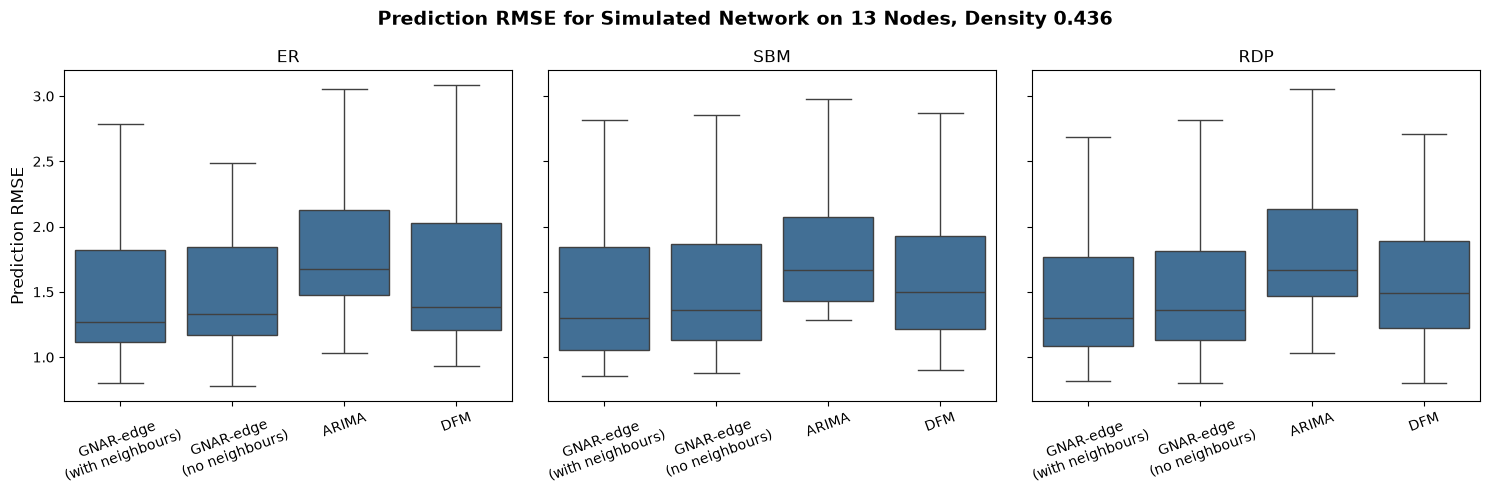

In [6]:
baboon_melted = baboon_comparison_df.melt(
    id_vars=["structure", "seed"],
    value_vars=["gnar_with_neighbours", "gnar_no_neighbours", "arima", "dfm"],
    var_name="model", value_name="rmse"
)

baboon_melted["model"] = baboon_melted["model"].replace({
    "gnar_with_neighbours": "GNAR-edge\n(with neighbours)",
    "gnar_no_neighbours": "GNAR-edge\n(no neighbours)",
    "arima": "ARIMA",
    "dfm": "DFM",
})

model_order = ["GNAR-edge\n(with neighbours)", "GNAR-edge\n(no neighbours)", "ARIMA", "DFM"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, structure in zip(axes, ["ER", "SBM", "RDP"]):
    subset = baboon_melted[baboon_melted["structure"] == structure]
    sns.boxplot(
        data=subset, x="model", y="rmse", order=model_order,
        color="#3470a3", showfliers=False, ax=ax,
    )
    ax.set_title(structure, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Prediction RMSE" if structure == "ER" else "", fontsize=12)
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("Prediction RMSE for Simulated Network on 13 Nodes, Density 0.436", fontsize=14, fontweight="bold")
save_figure(fig, "baboon_scale_prediction_comparison")
plt.show()

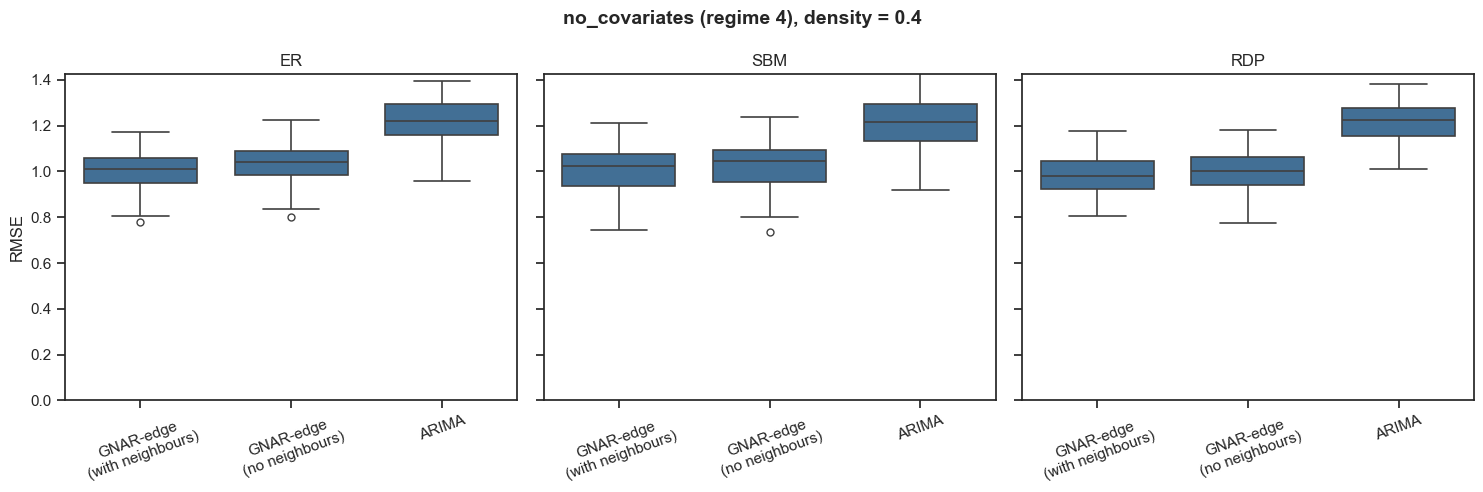

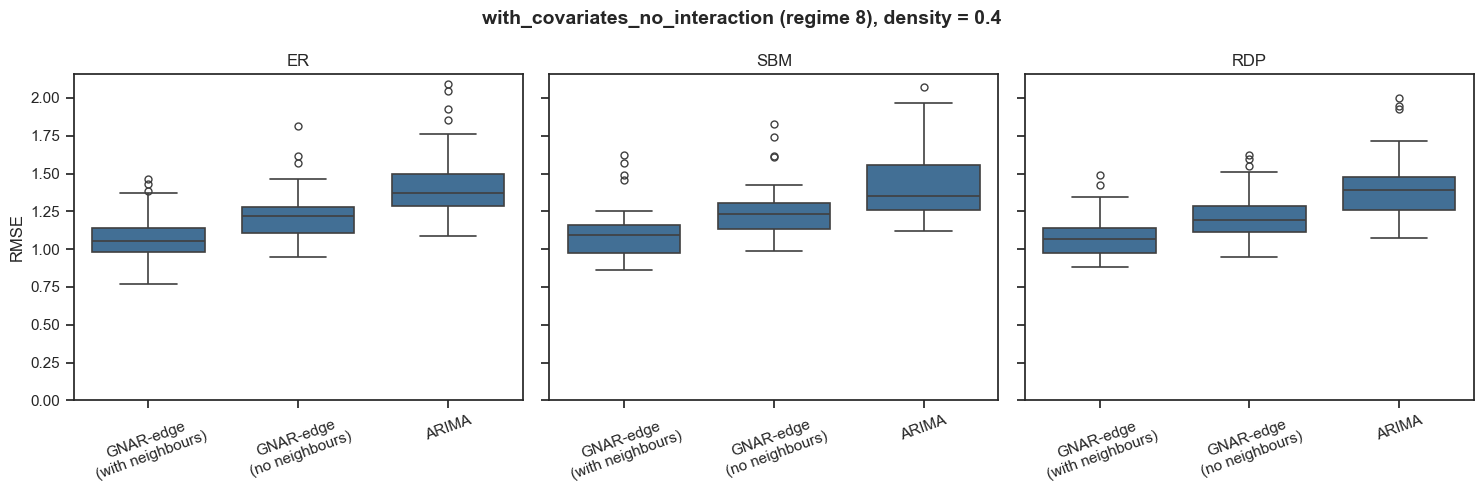

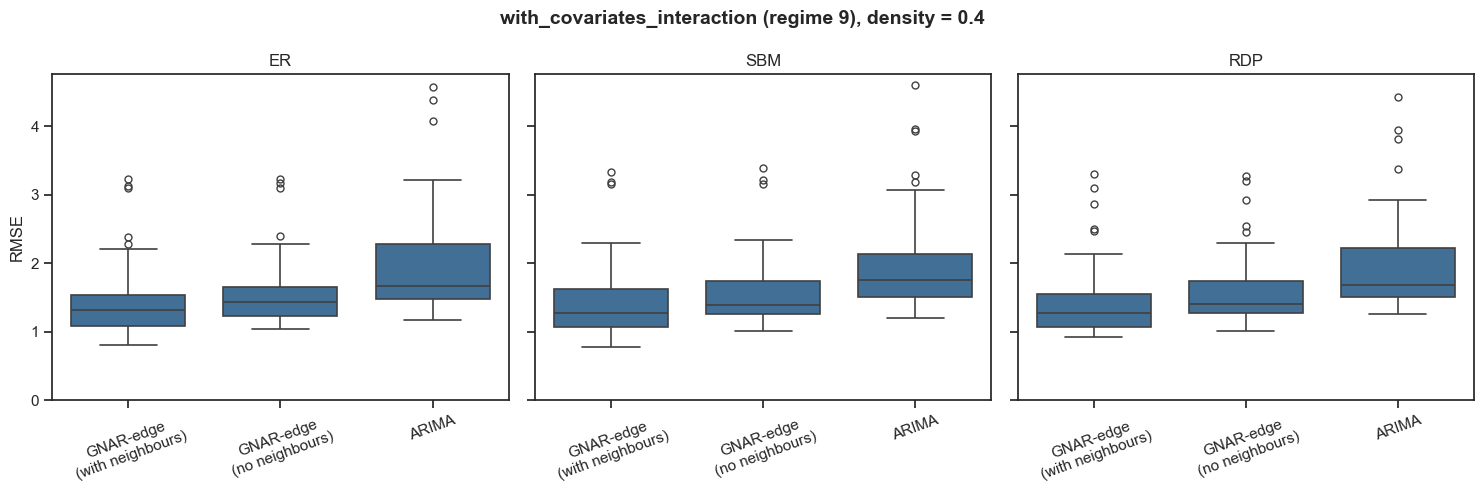

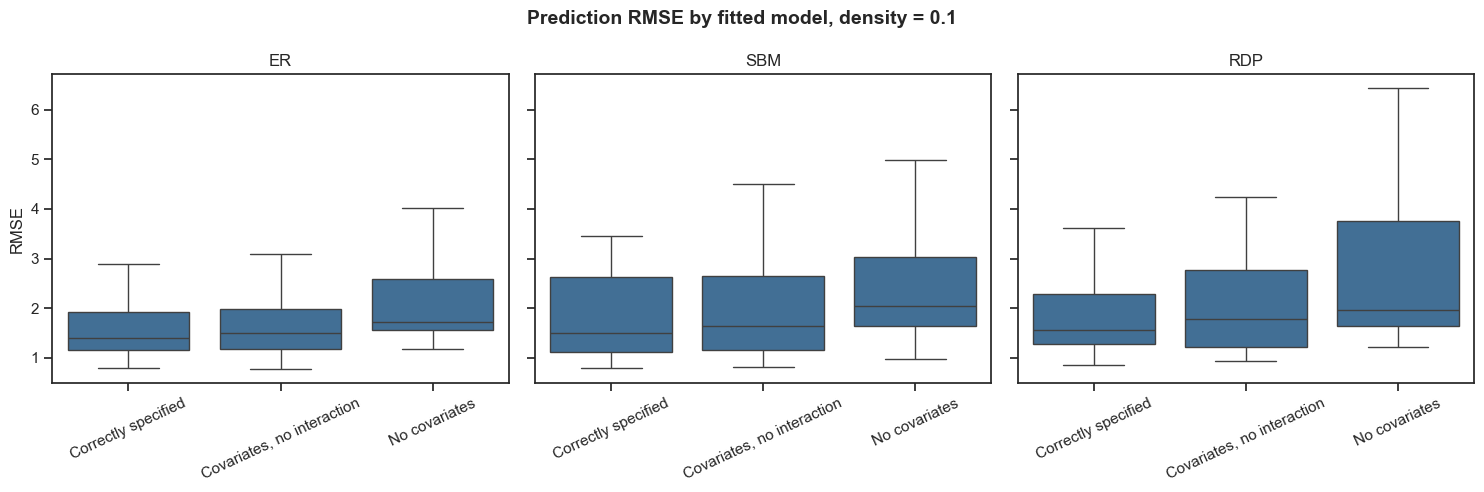

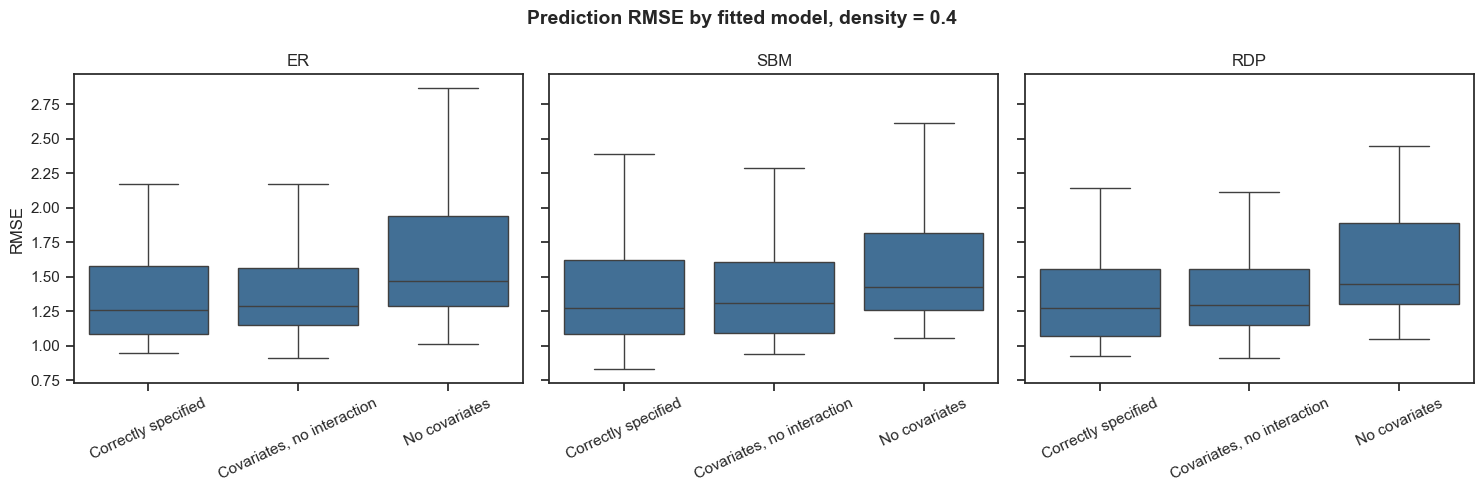

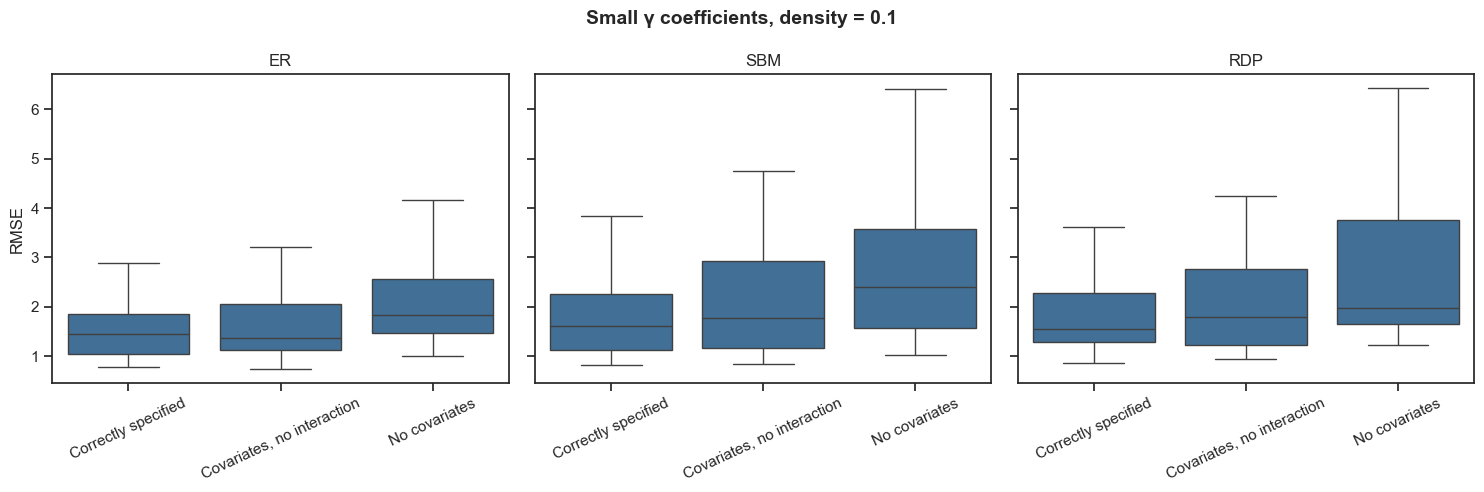

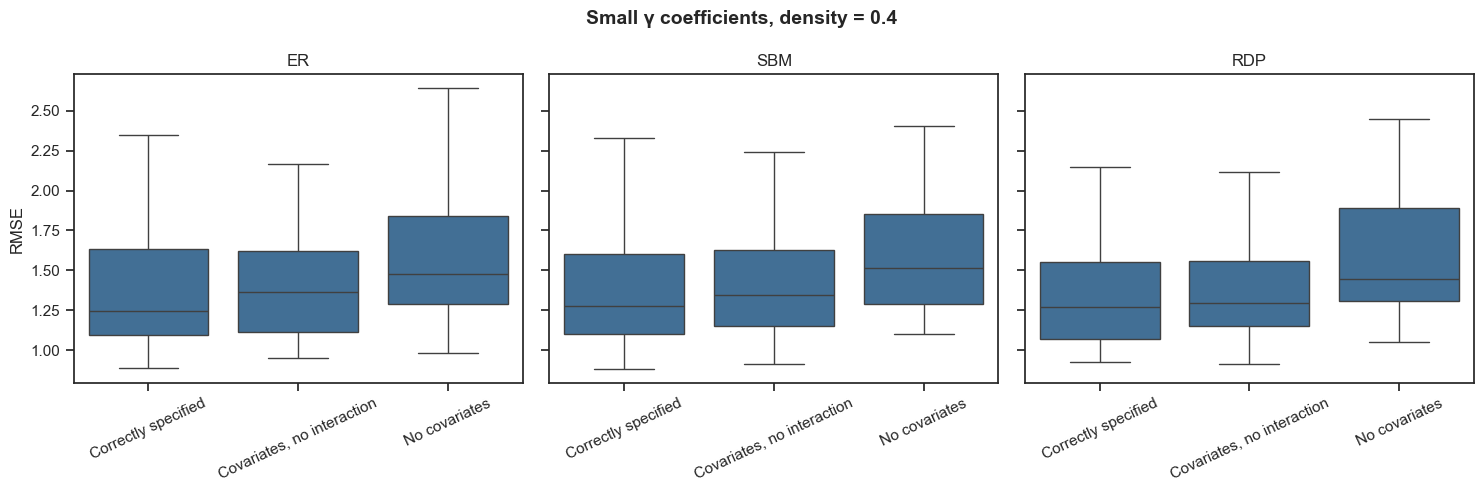

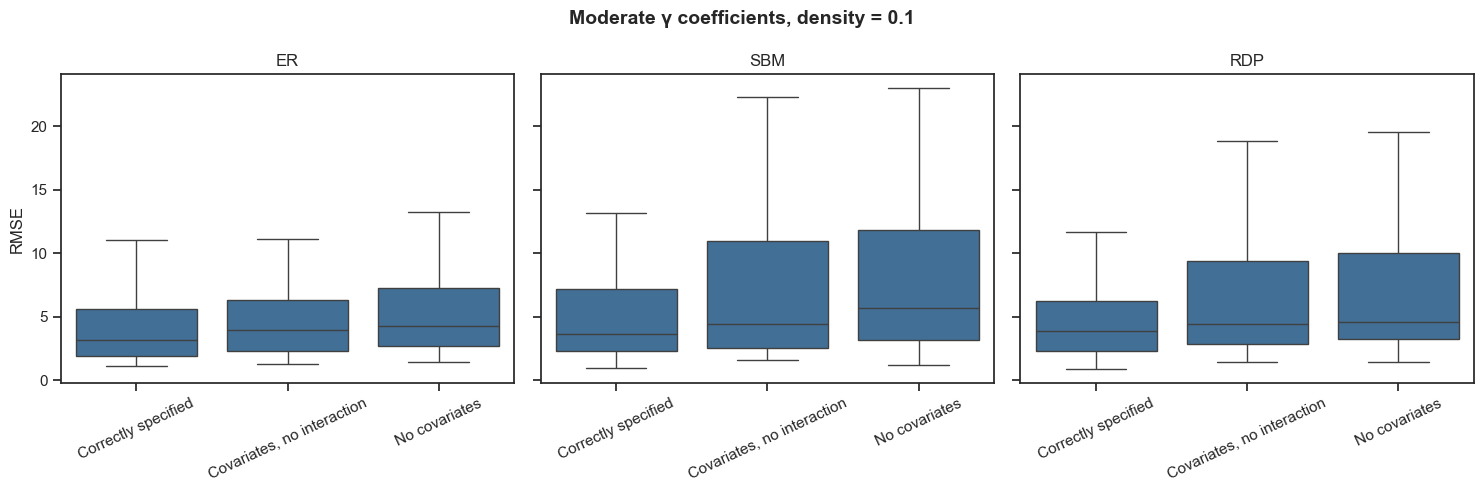

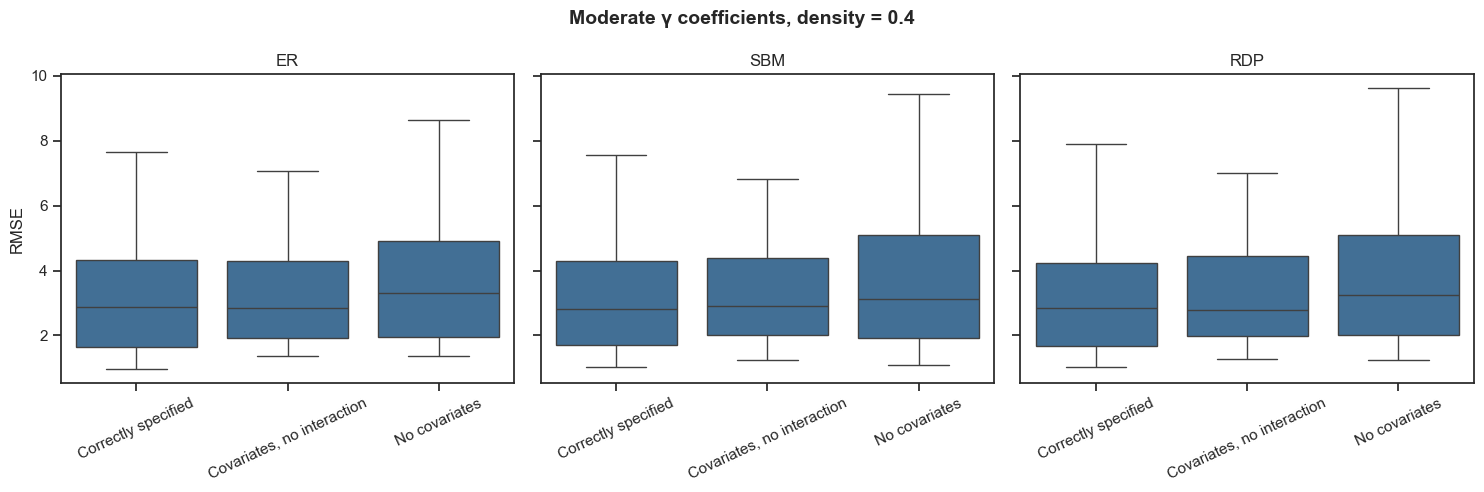

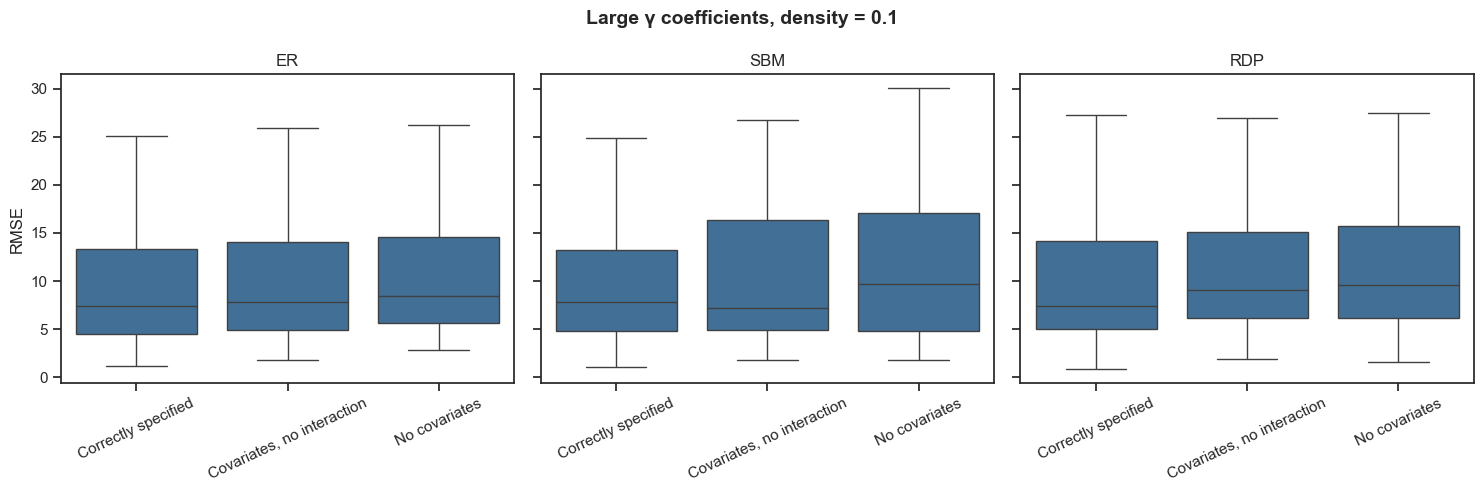

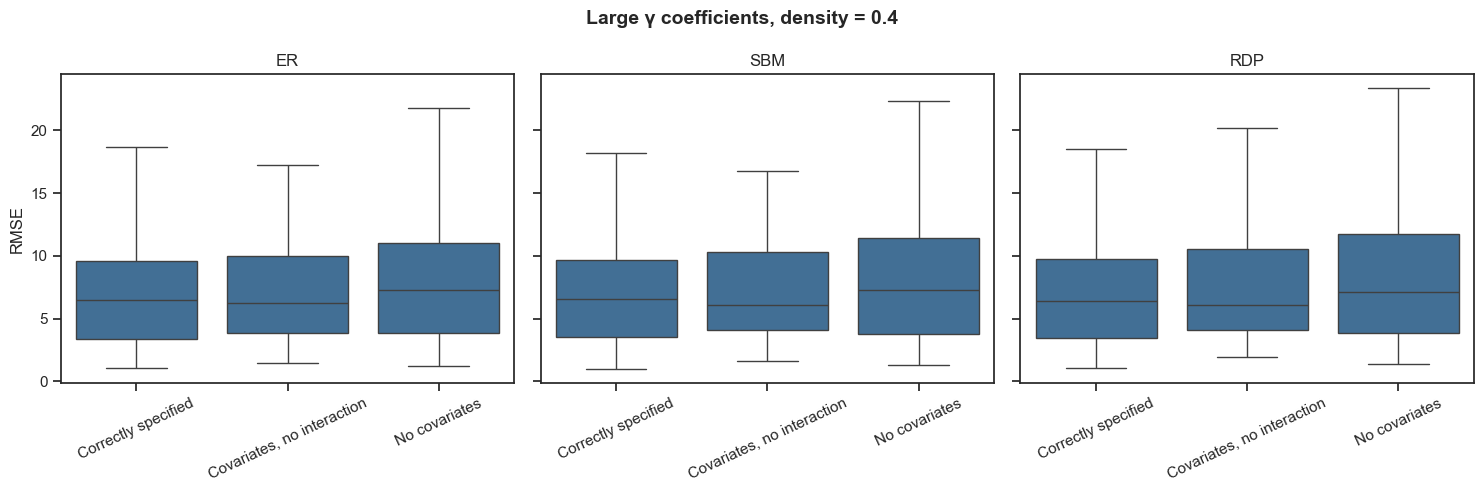

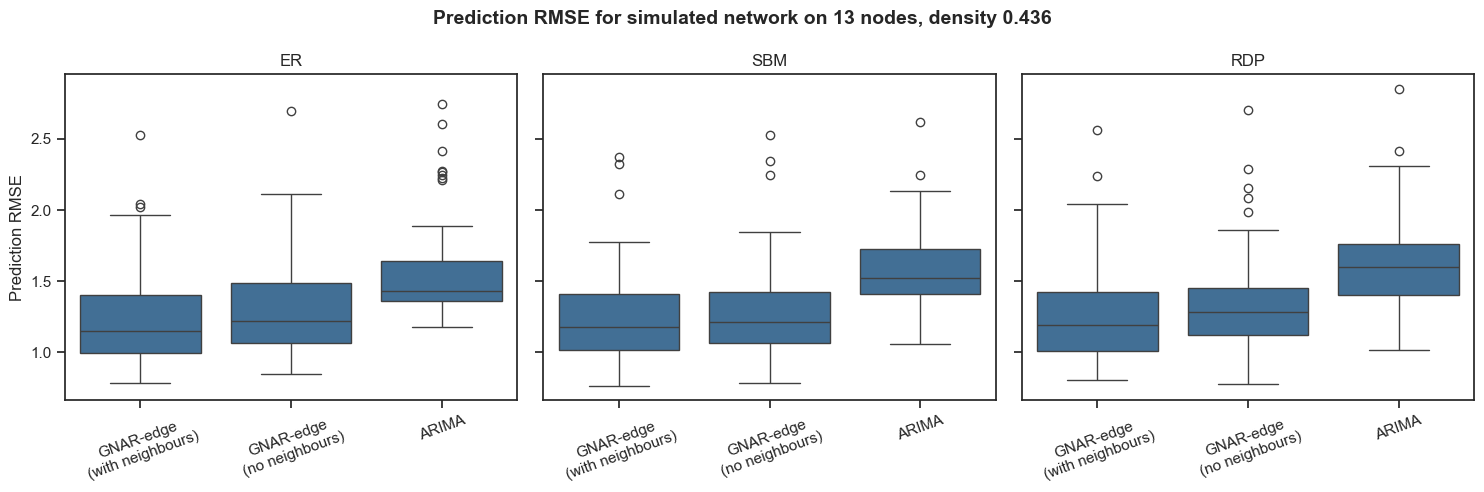

In [ ]:
#correctly-specified vs. covariate configurations,
plot_df = comparison_df.melt(
    id_vars=["structure", "density"],
    value_vars=["correctly_specified", "covariates_no_interaction", "no_covariates_fitted"],
    var_name="fitted_model", value_name="rmse"
)

#renaming models for presentation purposes
model_order = ["correctly_specified", "covariates_no_interaction", "no_covariates_fitted"]
model_labels = {
    "correctly_specified": "Correctly specified",
    "covariates_no_interaction": "Covariates, no interaction",
    "no_covariates_fitted": "No covariates",
}
plot_df["fitted_model"] = pd.Categorical(plot_df["fitted_model"], categories=model_order, ordered=True)
plot_df["fitted_model_label"] = plot_df["fitted_model"].map(model_labels)

for density in [0.4]:
    subset = plot_df[plot_df["density"] == density]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

    for ax, structure in zip(axes, ["ER", "SBM", "RDP"]):
        s = subset[subset["structure"] == structure]
        sns.boxplot(
            data=s, x="fitted_model_label", y="rmse",
            order=["Correctly specified", "Covariates, no interaction", "No covariates"],
            color="#3470a3", showfliers=False, ax=ax,
        )
        ax.set_title(structure, fontsize=12)
        ax.set_xlabel("")
        ax.set_ylabel("RMSE" if structure == "ER" else "", fontsize=12)
        ax.tick_params(axis="x", rotation=25)

    fig.suptitle(f"Prediction RMSE by fitted model, density = {density}", fontsize=14, fontweight="bold")
    save_figure(fig, f"correctly_specified_comparison_density{str(density).replace('.', '')}")


#exogenous-covariate-scale sweep (small/moderate/large)
plot_df_gamma = gamma_scale_df.melt(
    id_vars=["gamma_scale", "structure", "density"],
    value_vars=["correctly_specified", "covariates_no_interaction", "no_covariates_fitted"],
    var_name="fitted_model", value_name="rmse",
)

plot_df_gamma["fitted_model"] = plot_df_gamma["fitted_model"].replace({
    "correctly_specified": "Correctly specified",
    "covariates_no_interaction": "Covariates, no interaction",
    "no_covariates_fitted": "No covariates",
})

model_order = ["Correctly specified", "Covariates, no interaction", "No covariates"]

for scale in ["small", "moderate", "large"]:
    for density in [0.4]:
        subset = plot_df_gamma[(plot_df_gamma["gamma_scale"] == scale) & (plot_df_gamma["density"] == density)]
        fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

        for ax, structure in zip(axes, ["ER", "SBM", "RDP"]):
            s = subset[subset["structure"] == structure]
            sns.boxplot(
                data=s, x="fitted_model", y="rmse", order=model_order,
                color="#3470a3", showfliers=False, ax=ax,
            )
            ax.set_title(structure, fontsize=12)
            ax.set_xlabel("")
            ax.set_ylabel("RMSE" if structure == "ER" else "", fontsize=12)
            ax.tick_params(axis="x", rotation=25)

        fig.suptitle(f"{scale.capitalize()} γ coefficients, density = {density}", fontsize=14, fontweight="bold")
        save_figure(fig, f"gamma_scale_{scale}_density{str(density).replace('.', '')}")

